# Exploratory Data Analysis
**Project:** Patient Satisfaction in Primary Healthcare Settings During the War in Sudan,
Eleskan75 Center, Karary Locality, Khartoum State – 2025

**Data analyst:** Abdulrahman Sirelkhatim

In [2]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 11

DATA_PATH = "../1_data/cleaned/cleaned_data.xlsx"
df = pd.read_excel(DATA_PATH)
print(f"Shape: {df.shape}")
df.head(3)

Shape: (357, 25)


,Age,age_grp,Gender,MaritalStatus,Occupation,displaced,care_expect,staff_comp,info_clarity,respect,...,meds_avail,conflict_affect,displacement,overall_sat,quality_mean,provider_mean,env_mean,conflict_mean,overall_index,sat_bin
0,28,21–30,2,2,Housewife,1,2,3,3,1,...,2,3,1,1,2.666667,1.666667,1.75,2.0,2.000000,0
1,31,31–40,2,2,Teacher,1,4,4,4,4,...,2,4,4,4,4.000000,4.000000,3.50,4.0,3.833333,1
2,37,31–40,2,2,Housewife,1,4,4,1,3,...,1,3,2,3,3.000000,3.333333,3.25,2.5,3.083333,0


## 1. Data Quality

In [3]:
print("Missing values per column:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "None")

print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"\nData types:\n{df.dtypes}")

Missing values per column:
None

Duplicate rows: 74

Data types:
Age                  int64
age_grp             object
Gender               int64
MaritalStatus        int64
Occupation          object
displaced            int64
care_expect          int64
staff_comp           int64
info_clarity         int64
respect              int64
doc_listen           int64
staff_concern        int64
hygiene              int64
safe                 int64
wait_time            int64
meds_avail           int64
conflict_affect      int64
displacement         int64
overall_sat          int64
quality_mean       float64
provider_mean      float64
env_mean           float64
conflict_mean      float64
overall_index      float64
sat_bin              int64
dtype: object


In [4]:
likert_cols = [
    "care_expect", "staff_comp", "info_clarity", "respect", "doc_listen",
    "staff_concern", "hygiene", "safe", "wait_time", "meds_avail",
    "conflict_affect", "displacement",
]

print("Likert item value ranges (should all be 1–5):")
for col in likert_cols:
    print(f"  {col}: min={df[col].min()}, max={df[col].max()}, n_unique={df[col].nunique()}")

Likert item value ranges (should all be 1–5):
  care_expect: min=1, max=5, n_unique=5
  staff_comp: min=1, max=5, n_unique=5
  info_clarity: min=1, max=5, n_unique=5
  respect: min=1, max=5, n_unique=5
  doc_listen: min=1, max=5, n_unique=5
  staff_concern: min=1, max=5, n_unique=5
  hygiene: min=1, max=5, n_unique=5
  safe: min=1, max=5, n_unique=5
  wait_time: min=1, max=5, n_unique=5
  meds_avail: min=1, max=5, n_unique=5
  conflict_affect: min=1, max=5, n_unique=5
  displacement: min=1, max=5, n_unique=5


## 2. Demographic Profile

In [5]:
n = len(df)

gender_counts = df["Gender"].map({1: "Male", 2: "Female"}).value_counts()
marital_counts = df["MaritalStatus"].map(
    {1: "Single", 2: "Married", 3: "Widowed", 4: "Divorced"}
).value_counts()
disp_counts = df["displaced"].map({0: "Resident", 1: "Displaced"}).value_counts()

print(f"N = {n}")
print(f"\nGender:\n{gender_counts.to_frame().assign(pct=lambda x: (x['count']/n*100).round(1))}")
print(f"\nMarital status:\n{marital_counts.to_frame().assign(pct=lambda x: (x['count']/n*100).round(1))}")
print(f"\nDisplacement:\n{disp_counts.to_frame().assign(pct=lambda x: (x['count']/n*100).round(1))}")
print(f"\nAge: mean={df['Age'].mean():.1f}, SD={df['Age'].std():.1f}, min={df['Age'].min()}, max={df['Age'].max()}")

N = 357

Gender:
        count   pct
Gender             
Female    308  86.3
Male       49  13.7

Marital status:
               count   pct
MaritalStatus             
Married          293  82.1
Single            29   8.1
Widowed           29   8.1
Divorced           6   1.7

Displacement:
           count   pct
displaced             
Displaced    254  71.1
Resident     103  28.9

Age: mean=29.7, SD=9.8, min=2, max=92


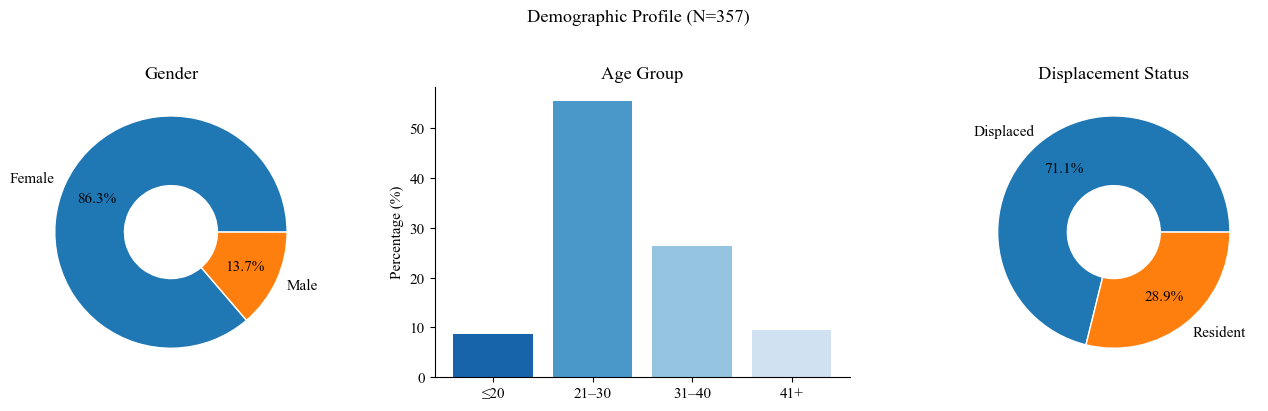

In [13]:
age_order = ["≤20", "21–30", "31–40", "41+"]
age_counts = df["age_grp"].value_counts().reindex(age_order)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%",
            wedgeprops={"width": 0.6, "edgecolor": "white"}, pctdistance=0.7)
axes[0].set_title("Gender")

axes[1].bar(age_order, age_counts / n * 100, color=sns.color_palette("Blues_r", 4))
axes[1].set_ylabel("Percentage (%)")
axes[1].set_title("Age Group")
axes[1].spines[["top", "right"]].set_visible(False)

axes[2].pie(disp_counts, labels=disp_counts.index, autopct="%1.1f%%",
            wedgeprops={"width": 0.6, "edgecolor": "white"}, pctdistance=0.7)
axes[2].set_title("Displacement Status")

plt.suptitle(f"Demographic Profile (N={n})", y=1.02)
plt.tight_layout()
plt.show()

In [7]:
occ_counts = df["Occupation"].value_counts()
print("Occupation distribution:")
print(occ_counts.to_frame().assign(pct=lambda x: (x["count"] / n * 100).round(1)))

Occupation distribution:
                                count   pct
Occupation                                 
Housewife                         237  66.4
Other                              53  14.8
Teacher                            16   4.5
Worker / Manual Labor / Driver     14   3.9
Unemployed                         13   3.6
Student                            11   3.1
Health Professional                11   3.1
Employee                            2   0.6


## 3. Satisfaction Score Distributions

In [14]:
domain_cols = ["quality_mean", "provider_mean", "env_mean", "conflict_mean", "overall_index"]
domain_labels = [
    "Quality of Care", "Patient–Provider", "Environment", "Conflict-Related", "Overall Index"
]

print("Domain score descriptive statistics:")
desc = df[domain_cols].describe().T
desc.index = domain_labels
print(desc[["count", "mean", "std", "min", "max"]].round(2))

Domain score descriptive statistics:
                  count  mean   std  min  max
Quality of Care   357.0  3.88  0.79  1.0  5.0
Patient–Provider  357.0  3.56  0.85  1.0  5.0
Environment       357.0  3.35  0.80  1.0  5.0
Conflict-Related  357.0  3.09  0.93  1.0  5.0
Overall Index     357.0  3.49  0.63  1.0  5.0


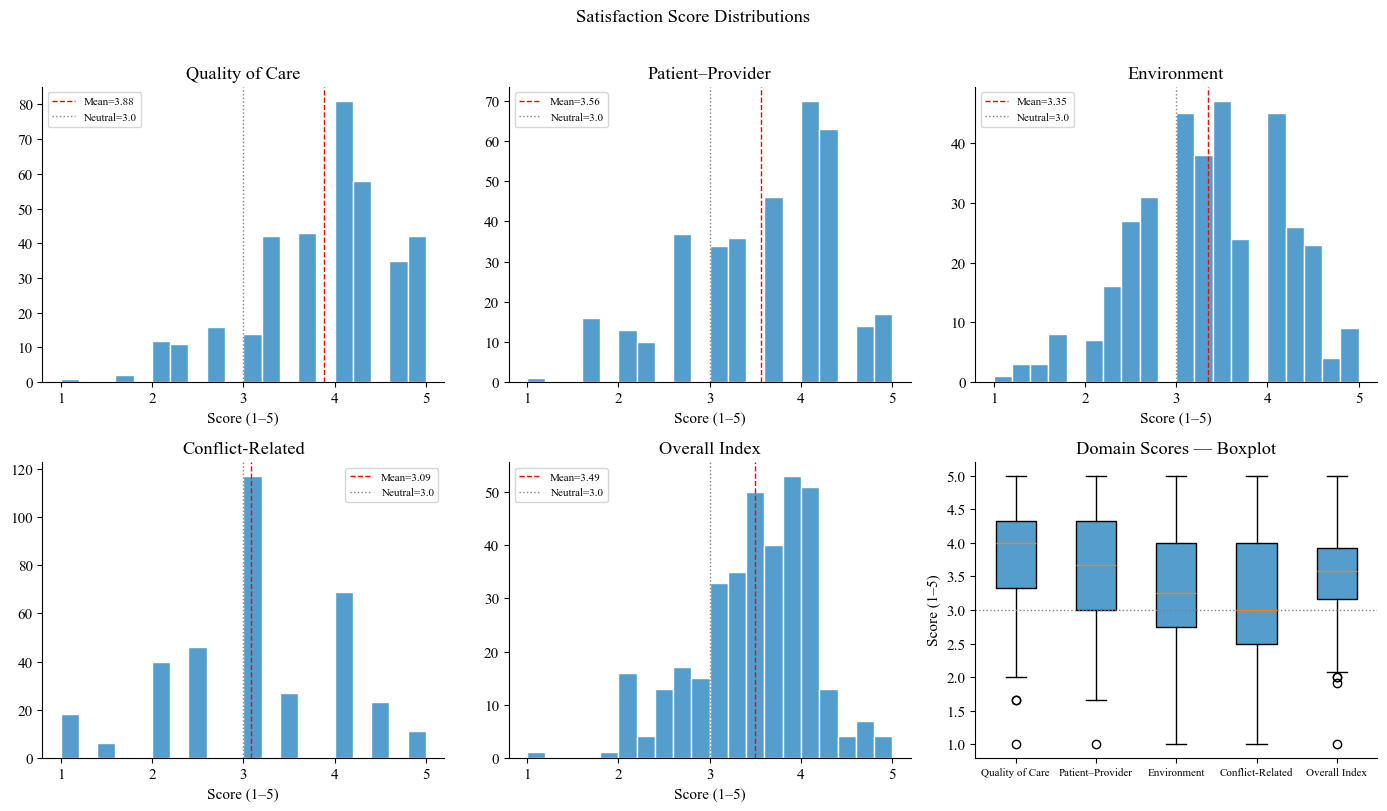

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, (col, label) in enumerate(zip(domain_cols, domain_labels)):
    axes[i].hist(df[col], bins=20, color=sns.color_palette("Blues_r", 6)[2], edgecolor="white")
    axes[i].axvline(df[col].mean(), color="red", linestyle="--", linewidth=1,
                    label=f"Mean={df[col].mean():.2f}")
    axes[i].axvline(3.0, color="gray", linestyle=":", linewidth=1, label="Neutral=3.0")
    axes[i].set_title(label)
    axes[i].set_xlabel("Score (1–5)")
    axes[i].legend(fontsize=8)
    axes[i].spines[["top", "right"]].set_visible(False)

axes[5].boxplot(
    [df[col].dropna() for col in domain_cols],
    labels=[label.split("/")[0].strip() for label in domain_labels],
    patch_artist=True,
    boxprops={"facecolor": sns.color_palette("Blues_r", 6)[2]},
)
axes[5].axhline(3.0, color="gray", linestyle=":", linewidth=1)
axes[5].set_ylabel("Score (1–5)")
axes[5].set_title("Domain Scores — Boxplot")
axes[5].tick_params(axis="x", labelsize=8)
axes[5].spines[["top", "right"]].set_visible(False)

plt.suptitle("Satisfaction Score Distributions", y=1.01)
plt.tight_layout()
plt.show()

In [16]:
sat_map = {1: "Very Dissatisfied", 2: "Dissatisfied", 3: "Neutral", 4: "Satisfied", 5: "Very Satisfied"}
sat_counts = df["overall_sat"].map(sat_map).value_counts()
print("Overall satisfaction (Q19) distribution:")
print(sat_counts.to_frame().assign(pct=lambda x: (x["count"] / n * 100).round(1)))
print(f"\nSatisfied (4–5): {(df['sat_bin']==1).sum()} ({(df['sat_bin']==1).mean()*100:.1f}%)")
print(f"Dissatisfied/Neutral (1–3): {(df['sat_bin']==0).sum()} ({(df['sat_bin']==0).mean()*100:.1f}%)")

Overall satisfaction (Q19) distribution:
                   count   pct
overall_sat                   
Very Satisfied       160  44.8
Satisfied            110  30.8
Neutral               37  10.4
Dissatisfied          32   9.0
Very Dissatisfied     18   5.0

Satisfied (4–5): 270 (75.6%)
Dissatisfied/Neutral (1–3): 87 (24.4%)


## 4. Item-Level Analysis

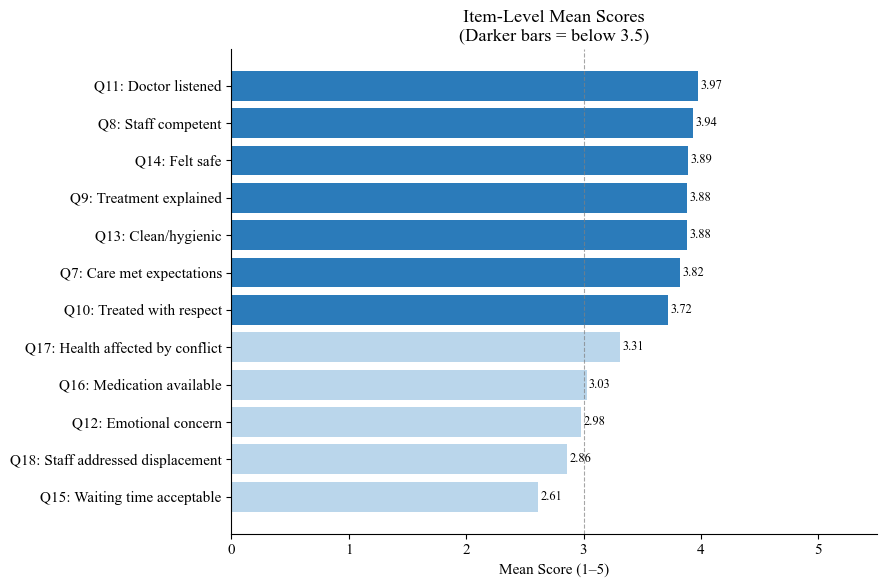

In [17]:
item_labels = [
    "Q7: Care met expectations",
    "Q8: Staff competent",
    "Q9: Treatment explained",
    "Q10: Treated with respect",
    "Q11: Doctor listened",
    "Q12: Emotional concern",
    "Q13: Clean/hygienic",
    "Q14: Felt safe",
    "Q15: Waiting time acceptable",
    "Q16: Medication available",
    "Q17: Health affected by conflict",
    "Q18: Staff addressed displacement",
]

item_means = df[likert_cols].mean().values
item_df = pd.DataFrame({"Item": item_labels, "Mean": item_means}).sort_values("Mean")

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(item_df["Item"], item_df["Mean"],
               color=[sns.color_palette("Blues_r", 6)[4] if v < 3.5
                      else sns.color_palette("Blues_r", 6)[1] for v in item_df["Mean"]])
for bar, v in zip(bars, item_df["Mean"]):
    ax.text(v + 0.02, bar.get_y() + bar.get_height() / 2, f"{v:.2f}",
            va="center", fontsize=9)
ax.axvline(3.0, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
ax.set_xlabel("Mean Score (1–5)")
ax.set_title("Item-Level Mean Scores\n(Darker bars = below 3.5)")
ax.set_xlim(0, 5.5)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [18]:
print("Percentage agreeing or strongly agreeing per item:")
for col, label in zip(likert_cols, item_labels):
    pct_agree = (df[col] >= 4).mean() * 100
    pct_disagree = (df[col] <= 2).mean() * 100
    print(f"  {label}: {pct_agree:.1f}% agree/strongly agree | {pct_disagree:.1f}% disagree/strongly disagree")

Percentage agreeing or strongly agreeing per item:
  Q7: Care met expectations: 75.9% agree/strongly agree | 13.2% disagree/strongly disagree
  Q8: Staff competent: 75.6% agree/strongly agree | 12.9% disagree/strongly disagree
  Q9: Treatment explained: 73.7% agree/strongly agree | 11.5% disagree/strongly disagree
  Q10: Treated with respect: 70.0% agree/strongly agree | 17.4% disagree/strongly disagree
  Q11: Doctor listened: 73.7% agree/strongly agree | 8.4% disagree/strongly disagree
  Q12: Emotional concern: 43.7% agree/strongly agree | 35.6% disagree/strongly disagree
  Q13: Clean/hygienic: 74.2% agree/strongly agree | 14.3% disagree/strongly disagree
  Q14: Felt safe: 74.8% agree/strongly agree | 11.8% disagree/strongly disagree
  Q15: Waiting time acceptable: 34.7% agree/strongly agree | 52.1% disagree/strongly disagree
  Q16: Medication available: 38.7% agree/strongly agree | 36.4% disagree/strongly disagree
  Q17: Health affected by conflict: 47.6% agree/strongly agree | 24.4%

## 5. Preliminary Associations

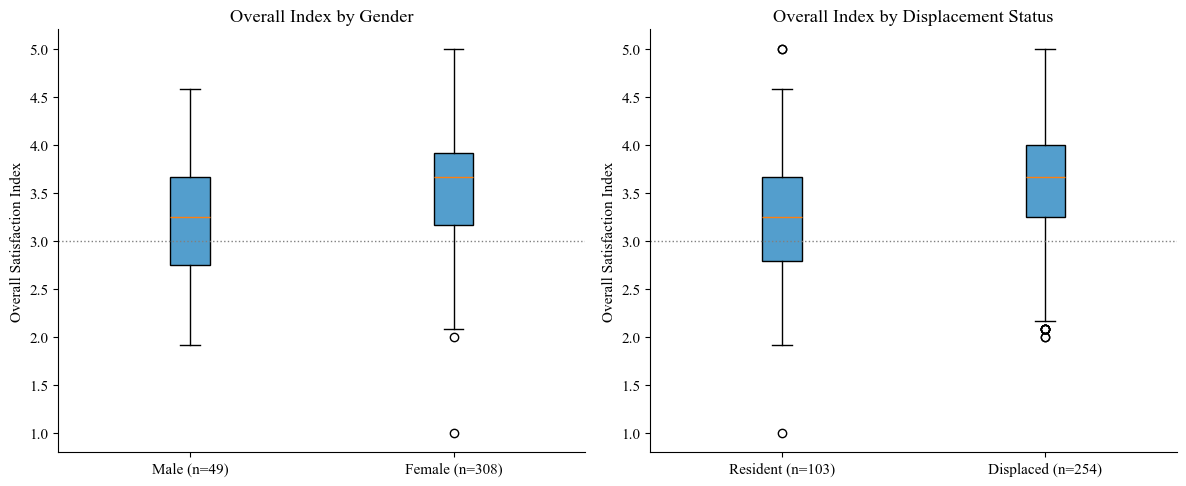

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

gender_groups = [
    df[df["Gender"] == 1]["overall_index"].dropna(),
    df[df["Gender"] == 2]["overall_index"].dropna(),
]
axes[0].boxplot(gender_groups, labels=["Male (n=49)", "Female (n=308)"],
                patch_artist=True,
                boxprops={"facecolor": sns.color_palette("Blues_r", 6)[2]})
axes[0].axhline(3.0, color="gray", linestyle=":", linewidth=1)
axes[0].set_ylabel("Overall Satisfaction Index")
axes[0].set_title("Overall Index by Gender")
axes[0].spines[["top", "right"]].set_visible(False)

disp_groups = [
    df[df["displaced"] == 0]["overall_index"].dropna(),
    df[df["displaced"] == 1]["overall_index"].dropna(),
]
axes[1].boxplot(disp_groups, labels=["Resident (n=103)", "Displaced (n=254)"],
                patch_artist=True,
                boxprops={"facecolor": sns.color_palette("Blues_r", 6)[2]})
axes[1].axhline(3.0, color="gray", linestyle=":", linewidth=1)
axes[1].set_ylabel("Overall Satisfaction Index")
axes[1].set_title("Overall Index by Displacement Status")
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

In [20]:
sat_by_gender = pd.crosstab(
    df["Gender"].map({1: "Male", 2: "Female"}),
    df["sat_bin"].map({0: "Dissatisfied/Neutral", 1: "Satisfied"}),
    normalize="index",
) * 100

print("Satisfaction rate by gender (%):")
print(sat_by_gender.round(1))

sat_by_disp = pd.crosstab(
    df["displaced"].map({0: "Resident", 1: "Displaced"}),
    df["sat_bin"].map({0: "Dissatisfied/Neutral", 1: "Satisfied"}),
    normalize="index",
) * 100

print("\nSatisfaction rate by displacement (%):")
print(sat_by_disp.round(1))

Satisfaction rate by gender (%):
sat_bin  Dissatisfied/Neutral  Satisfied
Gender                                  
Female                   21.1       78.9
Male                     44.9       55.1

Satisfaction rate by displacement (%):
sat_bin    Dissatisfied/Neutral  Satisfied
displaced                                 
Displaced                  22.4       77.6
Resident                   29.1       70.9


## 6. Correlation Analysis

In [21]:
print("Spearman correlations: individual items vs overall satisfaction (Q19)")
for col, label in zip(likert_cols, item_labels):
    r, p = stats.spearmanr(df[col].dropna(), df.loc[df[col].notna(), "overall_sat"])
    sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))
    print(f"  {label}: ρ = {r:.3f}, p = {p:.3f} {sig}")

Spearman correlations: individual items vs overall satisfaction (Q19)
  Q7: Care met expectations: ρ = 0.369, p = 0.000 ***
  Q8: Staff competent: ρ = 0.379, p = 0.000 ***
  Q9: Treatment explained: ρ = 0.407, p = 0.000 ***
  Q10: Treated with respect: ρ = 0.312, p = 0.000 ***
  Q11: Doctor listened: ρ = 0.279, p = 0.000 ***
  Q12: Emotional concern: ρ = 0.305, p = 0.000 ***
  Q13: Clean/hygienic: ρ = 0.384, p = 0.000 ***
  Q14: Felt safe: ρ = 0.575, p = 0.000 ***
  Q15: Waiting time acceptable: ρ = 0.380, p = 0.000 ***
  Q16: Medication available: ρ = 0.300, p = 0.000 ***
  Q17: Health affected by conflict: ρ = 0.063, p = 0.234 
  Q18: Staff addressed displacement: ρ = 0.265, p = 0.000 ***


In [22]:
print("Pearson correlations: domain means vs overall index")
domain_names = ["Quality", "Provider", "Environment", "Conflict", "Overall Index"]
for col, label in zip(domain_cols, domain_names):
    r, p = stats.pearsonr(df[col].dropna(), df.loc[df[col].notna(), "overall_index"])
    print(f"  {label}: r = {r:.3f}, p = {p:.4f}")

print("\nCorrelation matrix (Pearson):")
corr_matrix = df[domain_cols].corr(method="pearson")
corr_matrix.index = domain_names
corr_matrix.columns = domain_names
print(corr_matrix.round(3))

Pearson correlations: domain means vs overall index
  Quality: r = 0.771, p = 0.0000
  Provider: r = 0.807, p = 0.0000
  Environment: r = 0.848, p = 0.0000
  Conflict: r = 0.503, p = 0.0000
  Overall Index: r = 1.000, p = 0.0000

Correlation matrix (Pearson):
               Quality  Provider  Environment  Conflict  Overall Index
Quality          1.000     0.570        0.549     0.122          0.771
Provider         0.570     1.000        0.524     0.269          0.807
Environment      0.549     0.524        1.000     0.301          0.848
Conflict         0.122     0.269        0.301     1.000          0.503
Overall Index    0.771     0.807        0.848     0.503          1.000


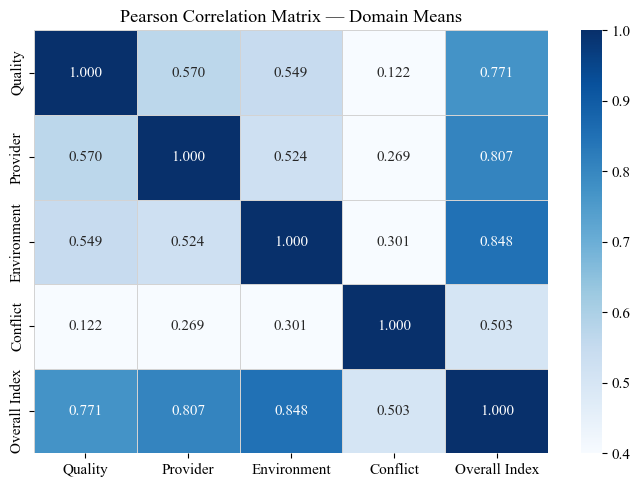

In [23]:
fig, ax = plt.subplots(figsize=(7, 5))
corr_display = df[domain_cols].corr(method="pearson")
corr_display.index = domain_names
corr_display.columns = domain_names

sns.heatmap(
    corr_display,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    vmin=0.4,
    vmax=1.0,
    linewidths=0.5,
    linecolor="lightgray",
    ax=ax,
)
ax.set_title("Pearson Correlation Matrix — Domain Means")
plt.tight_layout()
plt.show()

## 7. EDA Findings Summary

| Finding | Value |
|---------|-------|
| Sample size | N = 357 |
| Female participants | 86.3% |
| Displaced due to conflict | 71.1% |
| Most common age group | 21–30 years (57.4%) |
| Most common occupation | Housewife (66.4%) |
| Overall satisfaction rate (Q19) | 75.6% satisfied |
| Highest-scoring domain | Quality of Medical Care (M = 3.88) |
| Lowest-scoring domain | Conflict-Related Circumstances (M = 3.09) |
| Most problematic item | Waiting time acceptable (52.1% disagree/strongly disagree) |
| Strongest item correlation with Q19 | Q14 Felt safe (ρ = 0.575) |
| Strongest domain correlation with overall index | Health Center Environment (r = 0.848) |
| Significant gender difference | Overall index (female M=3.54 vs male M=3.20, p=0.001) |
| Significant marital status effect | ANOVA F(3,353) = 3.28, p = 0.021 |
| Displacement vs satisfaction | Not significant (p = 0.183) |